# Level 5 — Data Mining Challenge: *The 1,000-Pick*

**규칙**: Set B (이미지 + 라벨 공개) 에서 **최대 1,000장** 을 선택하여 학습 셋에 추가하고, best 모델을 다시 학습하세요.

> **Set B 의 라벨이 공개되어 있다는 점에 주의**하세요. 본 Level 의 평가 본질은 "*주어진 풀에서 어떤 1,000장이 가장 가치 있는가*" — 즉, 라벨을 알고 있다고 가정한 상태에서의 효율적인 부분집합 선택입니다.

**본 PA에서 가장 큰 비중 (25%)** 을 차지하는 Level 입니다. 어떤 *알고리즘* 으로 1,000장을 골랐는지 — 그 *근거* — 가 변별력의 본진입니다. Curation Report 로 정리합니다.

채점 메트릭:
$$\text{DI} = \frac{\text{Avg-MF1}(\text{본인 picks}) - \text{Avg-MF1}(\text{random picks})}{\text{Avg-MF1}(\text{random picks})}$$

## 검토해 볼 만한 전략

| 전략 | 핵심 아이디어 | Set B 라벨 활용 |
|---|---|---|
| 클래스 균형 (Class Balancing) | Set A 에서 부족한 속성 클래스 (foggy / dawn-dusk 등) 를 채워 넣음 | ✅ 라벨로 직접 필터링 |
| Hard Example Mining | base 모델의 confidence 가 낮은 / 예측이 라벨과 다른 이미지를 우선 선택 | ✅ 모델 예측 vs 정답 비교 |
| 다양성 (Core-Set) | Set B 의 feature space 를 가장 잘 커버하는 부분집합 선택 (k-center / clustering) | 라벨 무관 |
| 결합 커버리지 | 속성 *조합* 의 균형을 맞춤 — 예: (snowy & night), (rainy & residential) | ✅ 라벨로 조합 카운트 |
| Loss 기반 | Set B 이미지에 대한 학습 직전 loss 가 큰 샘플 우선 | ✅ 라벨 필요 |

위 전략들을 결합/응용/대체할 수 있습니다. **Curation Report 에 본인의 의사결정 근거를 명확히 기술** 하세요.

**산출물**: `level5_picks.json` — 선택한 image_id 리스트 (이미지별 메타데이터 포함 가능).

In [1]:
import os
import sys

repo_url  = "https://github.com/Seongha-parkk/2026-HYU-AUE8088-PA2.git"
repo_name = "2026-HYU-AUE8088-PA2"

if not os.path.exists(f"/content/{repo_name}"):
    !git clone {repo_url}
else:
    !git -C /content/{repo_name} pull

%cd /content/{repo_name}

%load_ext autoreload
%autoreload 2

!pip install -q -r requirements.txt

Already up to date.
/content/2026-HYU-AUE8088-PA2


In [2]:
from google.colab import drive
import os

drive.mount('/drive')

DRIVE_CKPT = "/drive/MyDrive/aue8088-pa2/checkpoints"
os.makedirs(DRIVE_CKPT, exist_ok=True)

LOCAL_CKPT = os.path.abspath("../checkpoints")
if os.path.islink(LOCAL_CKPT):
    print(f"symlink 이미 존재: {LOCAL_CKPT} → {os.readlink(LOCAL_CKPT)}")
elif os.path.isdir(LOCAL_CKPT):
    import shutil
    for f in os.listdir(LOCAL_CKPT):
        shutil.move(os.path.join(LOCAL_CKPT, f), DRIVE_CKPT)
    shutil.rmtree(LOCAL_CKPT)
    os.symlink(DRIVE_CKPT, LOCAL_CKPT)
    print(f"기존 파일 Drive 이전 후 symlink 생성: {LOCAL_CKPT} → {DRIVE_CKPT}")
else:
    os.symlink(DRIVE_CKPT, LOCAL_CKPT)
    print(f"symlink 생성: {LOCAL_CKPT} → {DRIVE_CKPT}")

Drive already mounted at /drive; to attempt to forcibly remount, call drive.mount("/drive", force_remount=True).
symlink 이미 존재: /content/checkpoints → /drive/MyDrive/aue8088-pa2/checkpoints


In [3]:
import math
import json
import numpy as np
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import transforms
from tqdm import tqdm

from src.utils.seed import set_seed, seed_worker
from src.utils.transforms import train_transform, eval_transform, IMAGENET_MEAN, IMAGENET_STD
from src.utils.trainer import MultiTaskTrainer, TrainConfig
from src.utils.wandb_logger import WandbLogger
from src.utils.metrics import collect_predictions, confusion_matrices, CLASS_NAMES, average_macro_f1
from src.utils.submission import write_submission
from src.datasets.bdd_attr import BDDAttrDataset, ATTRIBUTES, NUM_CLASSES
from src.datasets.samplers import multi_attr_balanced_sampler
from src.losses.imbalanced import FocalLoss
from src.augment.mix import cutmix_data, mixed_loss
from src.models.vit import vit_small_patch16_224

SEED = 42
set_seed(SEED, deterministic=True)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [4]:
import wandb; wandb.login()

WANDB_PROJECT = "aue8088-pa2"
STRATEGY_NAME = "ir-rarity+uncertainty"
WANDB_TAGS    = ["level5", STRATEGY_NAME]

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.
wandb: Currently logged in as: qkrtjdgk16 (qkrtjdgk16-hanyang-university) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


In [5]:
# ../data/set_a 가 없으면 zip 을 받아 상위 폴더에 압축 해제 → ../data/set_a, ../data/set_b 생성.
import os, sys, zipfile, subprocess

GDRIVE_FILE_ID = "1L7YC70QlO87aIbE5lbtQ94HUINJijBKK"
ZIP_PATH   = "../aue8088_pa2_data.zip"
EXTRACT_TO = ".."   # zip 내부 최상위가 data/ 이므로 상위 폴더에 풀면 ../data/... 가 됨
DATA_ROOT = "../data/set_a"

if not os.path.isdir(DATA_ROOT):
    try:
        import gdown
    except ImportError:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", "gdown"], check=True)
        import gdown

    if not os.path.exists(ZIP_PATH):
        print("데이터셋 zip 다운로드 중...")
        gdown.download(id=GDRIVE_FILE_ID, output=ZIP_PATH, quiet=False)

    print("압축 해제 중...")
    with zipfile.ZipFile(ZIP_PATH) as zf:
        zf.extractall(EXTRACT_TO)
    print(f"완료 → {DATA_ROOT}")
else:
    print(f"데이터셋이 이미 존재합니다 → {DATA_ROOT}")


데이터셋이 이미 존재합니다 → ../data/set_a


In [6]:
BEST_CKPT = "../checkpoints/level3_vit-pretrained+ir-focal+ir-sampler+randaug+cutmix.pth"
model = vit_small_patch16_224().to(device)
model.load_state_dict(torch.load(BEST_CKPT, map_location=device)["state_dict"])
model.eval()

train_ds_a = BDDAttrDataset("../data/set_a", "train", transform=eval_transform())
set_a_counts = {a: train_ds_a.class_counts(a).float() for a in ATTRIBUTES}
IR = {a: (set_a_counts[a].max() / set_a_counts[a][set_a_counts[a] > 0].min()).item()
      for a in ATTRIBUTES}
ir_total = sum(IR.values())
print("Set A IR:", {a: round(v, 1) for a, v in IR.items()})

set_b    = BDDAttrDataset("../data/set_b", split="mining", transform=eval_transform())
loader_b = DataLoader(set_b, batch_size=128, shuffle=False, num_workers=2)
preds_b, probs_b, _, ids_b = collect_predictions(model, loader_b, device)

# ── Signal 1: IR-weighted rarity score (Set A 희귀 클래스 보충 우선) ──────
rarity = np.zeros(len(set_b))
for i, s in enumerate(set_b.samples):
    for a in ATTRIBUTES:
        label = getattr(s, a)
        if label >= 0:
            rarity[i] += (IR[a] / ir_total) / max(set_a_counts[a][label].item(), 1)

# ── Signal 2: Uncertainty (모델이 틀릴 가능성이 높은 샘플 우선) ───────────
max_probs   = np.stack([probs_b[a].max(axis=-1) for a in ATTRIBUTES], axis=1)
uncertainty = 1.0 - max_probs.mean(axis=1)

# ── 결합 점수 (정규화 후 가중 합산) ─────────────────────────────────────
def norm01(x):
    return (x - x.min()) / (x.max() - x.min() + 1e-8)

score = 0.7 * norm01(rarity) + 0.3 * norm01(uncertainty)
print(f"Set B 총 {len(set_b)}장 | rarity mean={rarity.mean():.4f} | unc mean={uncertainty.mean():.3f}")

Set A IR: {'weather': 15.5, 'scene': 5.4, 'timeofday': 6.3}
Set B 총 15000장 | rarity mean=0.0011 | unc mean=0.388


In [7]:
K     = 1000
order = np.argsort(-score)[:K]

picks = []
for i in order:
    s = set_b.samples[i]
    picks.append({
        "image_id":    s.image_id,
        "weather":     int(s.weather),
        "scene":       int(s.scene),
        "timeofday":   int(s.timeofday),
        "score":       float(score[i]),
        "rarity":      float(rarity[i]),
        "uncertainty": float(uncertainty[i]),
    })

with open("../level5_picks.json", "w") as f:
    json.dump({
        "strategy": (
            "IR-weighted rarity score (0.7) + model uncertainty (1-max_softmax, 0.3) 결합. "
            "Set A의 속성별 IR을 기준으로 희귀 클래스 조합을 가진 이미지에 높은 가중치를 부여하고, "
            "level3 ViT 모델이 예측에 불확실한 샘플을 추가로 우선 선택."
        ),
        "num_picks": len(picks),
        "picks": picks,
    }, f, indent=2)

picks_A         = picks.copy()
STRATEGY_NAME_A = STRATEGY_NAME
WANDB_TAGS_A    = list(WANDB_TAGS)

from collections import Counter
print(f"\n선별된 {K}장 분포:")
for a in ATTRIBUTES:
    cnt  = Counter(p[a] for p in picks)
    dist = {CLASS_NAMES[a][k]: cnt.get(k, 0) for k in range(NUM_CLASSES[a])}
    print(f"  {a}: {dist}")


선별된 1000장 분포:
  weather: {'clear': 0, 'overcast': 0, 'rainy': 0, 'snowy': 1000, 'foggy': 0, 'partly cloudy': 0}
  scene: {'city street': 634, 'highway': 135, 'residential': 231}
  timeofday: {'daytime': 498, 'night': 348, 'dawn/dusk': 154}


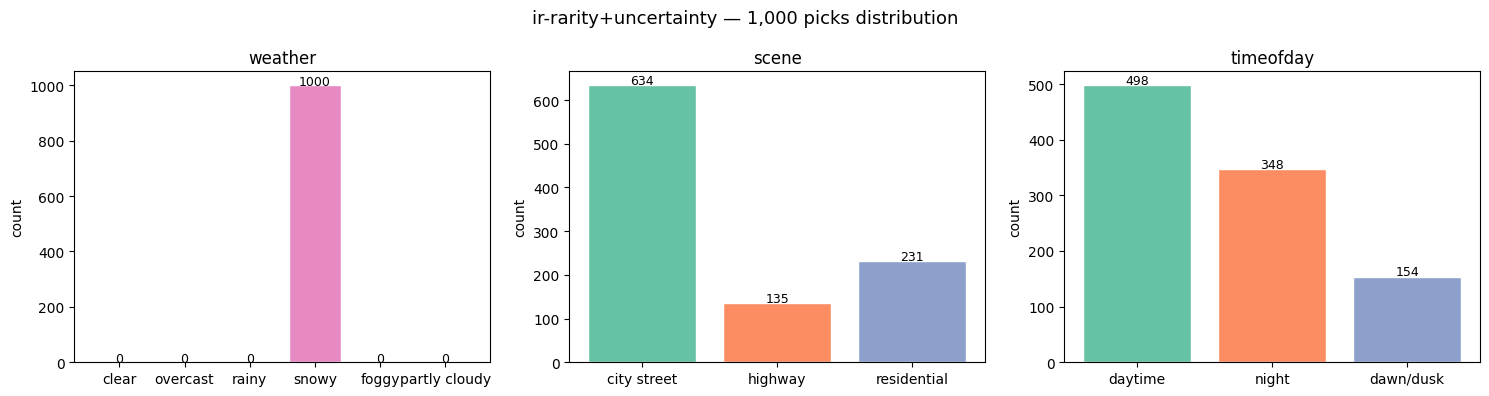

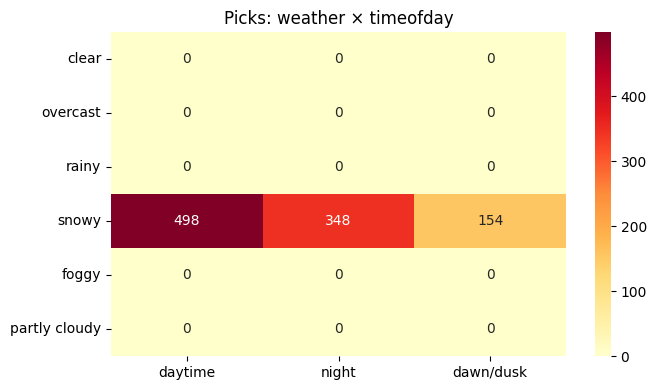

✓ level5_picks_bar.png / level5_picks_heatmap.png 저장


In [8]:
# ── Picks 분포 시각화 (bar chart + heatmap) ───────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, a in zip(axes, ATTRIBUTES):
    cnt  = Counter(p[a] for p in picks_A)
    vals = [cnt.get(k, 0) for k in range(NUM_CLASSES[a])]
    bars = ax.bar(CLASS_NAMES[a], vals,
                  color=plt.cm.Set2.colors[:len(vals)], edgecolor="white")
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, v + 2, str(v),
                ha="center", fontsize=9)
    ax.set_title(a, fontsize=12)
    ax.set_ylabel("count")
fig.suptitle(f"{STRATEGY_NAME_A} — 1,000 picks distribution", fontsize=13)
fig.tight_layout()
plt.savefig("../level5_picks_bar.png", dpi=150, bbox_inches="tight")
plt.show()

cross = np.zeros((NUM_CLASSES["weather"], NUM_CLASSES["timeofday"]), dtype=int)
for p in picks_A:
    cross[p["weather"], p["timeofday"]] += 1
fig2, ax2 = plt.subplots(figsize=(7, 4))
sns.heatmap(cross, annot=True, fmt="d", cmap="YlOrRd",
            xticklabels=CLASS_NAMES["timeofday"],
            yticklabels=CLASS_NAMES["weather"], ax=ax2)
ax2.set_title("Picks: weather × timeofday")
fig2.tight_layout()
plt.savefig("../level5_picks_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ level5_picks_bar.png / level5_picks_heatmap.png 저장")

In [9]:
import torch.nn.functional as F_nn
from torchvision import transforms

# ── Level5 학습 augmentation (전략 공통) ─────────────────────────────────
def train_transform_l5(img_size=224):
    return transforms.Compose([
        transforms.RandomResizedCrop(img_size, scale=(0.7, 1.0)),
        transforms.RandomHorizontalFlip(),
        transforms.RandAugment(num_ops=2, magnitude=9),
        transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
        transforms.ToTensor(),
        transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    ])

# ── Score 1: 순수 불확실성 (1 - max_softmax) ─────────────────────────────
score_unc = norm01(uncertainty)

# ── Score 2: Feature Diversity (확률 공간 코사인 유사도 역수) ─────────────
loader_a_inf = DataLoader(train_ds_a, batch_size=128, shuffle=False, num_workers=2)
_, probs_a_dict, _, _ = collect_predictions(model, loader_a_inf, device)

feats_b = np.concatenate([probs_b[a] for a in ATTRIBUTES], axis=1).astype(np.float32)
feats_a = np.concatenate([probs_a_dict[a] for a in ATTRIBUTES], axis=1).astype(np.float32)
fb_n = F_nn.normalize(torch.tensor(feats_b, device=device), dim=1)
fa_n = F_nn.normalize(torch.tensor(feats_a, device=device), dim=1)
diversity_score = np.zeros(len(set_b))
for _i in range(0, len(set_b), 256):
    sim = (fb_n[_i:_i+256] @ fa_n.T).max(dim=1).values
    diversity_score[_i:_i+256] = (1 - sim).cpu().numpy()
diversity_score = norm01(diversity_score)
print(f"diversity   score: mean={diversity_score.mean():.4f}  max={diversity_score.max():.4f}")

# ── Score 3: Pure CE Loss (IR 가중치 없이 합산) ───────────────────────────
ce_loss_score = np.zeros(len(set_b))
model.eval()
_off = 0
with torch.no_grad():
    for batch in DataLoader(set_b, batch_size=128, shuffle=False, num_workers=2):
        imgs   = batch["image"].to(device)
        logits = model(imgs); B = imgs.size(0)
        ce_loss_score[_off:_off+B] = sum(
            F_nn.cross_entropy(logits[a], batch[a].to(device), reduction="none")
            for a in ATTRIBUTES
        ).cpu().numpy()
        _off += B
ce_loss_score = norm01(ce_loss_score)
print(f"CE loss     score: mean={ce_loss_score.mean():.4f}  max={ce_loss_score.max():.4f}")

# ── Score 4: Minority-Error (소수 클래스 오예측 → tier1, 소수 클래스 → tier2) ─
_minority_labels = {}
for a in ATTRIBUTES:
    median_c = set_a_counts[a][set_a_counts[a] > 0].median().item()
    _minority_labels[a] = {c for c in range(NUM_CLASSES[a])
                           if set_a_counts[a][c].item() < median_c}
_tier = np.full(len(set_b), 3)
for i, s in enumerate(set_b.samples):
    is_minority = any(getattr(s, a) in _minority_labels[a] for a in ATTRIBUTES)
    is_wrong    = any(preds_b[a][i] != getattr(s, a) for a in ATTRIBUTES)
    if is_minority and is_wrong: _tier[i] = 1
    elif is_minority:             _tier[i] = 2
minority_error_score = norm01(-_tier * 10 + uncertainty)
print(f"minority-error   : tier1(소수+오예측)={(_tier==1).sum()}  tier2(소수)={(_tier==2).sum()}  tier3={(_tier==3).sum()}")

# ── 공통 헬퍼: score 기준 상위 K장 선정 → FocalLoss + IR sampler + CutMix 재학습 ──
def _retrain_strategy(score_arr, strategy_name, K=1000, save_path=None, wandb_tags=None):
    """score_arr 상위 K장 선정 → 30에포크 재학습 → (MF1, model) 반환. 전 전략 공통 파이프라인."""
    if save_path and os.path.exists(save_path):
        m_s = vit_small_patch16_224().to(device)
        m_s.load_state_dict(torch.load(save_path, map_location=device)["state_dict"])
        m_s.eval()
        _ds_val = BDDAttrDataset("../data/set_a", "val", transform=eval_transform())
        _ld_val = DataLoader(_ds_val, batch_size=64, shuffle=False, num_workers=2, pin_memory=True)
        prd, _, tgt, _ = collect_predictions(m_s, _ld_val, device)
        final_mf1 = average_macro_f1(prd, tgt)
        print(f"{strategy_name} ← {save_path}  MF1={final_mf1:.4f}")
        return final_mf1, m_s
    tags  = wandb_tags or ["level5", strategy_name]
    order = np.argsort(-score_arr)[:K]
    extra = [(set_b.samples[i].image_id, set_b.samples[i].weather,
              set_b.samples[i].scene,    set_b.samples[i].timeofday)
             for i in order]

    ds_tr  = BDDAttrDataset("../data/set_a", "train",
                             transform=train_transform_l5(), extra_picks=extra)
    ds_val = BDDAttrDataset("../data/set_a", "val", transform=eval_transform())

    IR_s     = {a: (ds_tr.class_counts(a).float().max()
                    / ds_tr.class_counts(a).float().clamp(min=1e-6).min()).item()
                for a in ATTRIBUTES}
    ir_s_tot = sum(IR_s.values())
    mw_s  = {a: IR_s[a] / ir_s_tot for a in ATTRIBUTES}
    lf_s  = {a: FocalLoss(gamma=round(1 + math.log(IR_s[a]), 1)).to(device) for a in ATTRIBUTES}
    samp_s = multi_attr_balanced_sampler(ds_tr, IR_s)

    ld_tr  = DataLoader(ds_tr,  batch_size=64, sampler=samp_s, num_workers=2, pin_memory=True)
    ld_val = DataLoader(ds_val, batch_size=64, shuffle=False,  num_workers=2, pin_memory=True)

    set_seed(SEED, deterministic=True)
    m_s   = vit_small_patch16_224().to(device)
    m_s.load_state_dict(torch.load(BEST_CKPT, map_location=device)["state_dict"])
    opt_s = torch.optim.AdamW(m_s.parameters(), lr=1e-4, weight_decay=5e-2)
    sch_s = torch.optim.lr_scheduler.CosineAnnealingLR(opt_s, T_max=30)

    lg_s = WandbLogger(
        project=WANDB_PROJECT,
        run_name=f"level5-{strategy_name}-K{K}",
        config={"strategy": strategy_name, "K": K, "epochs": 30},
        tags=tags,
    )

    for epoch in range(30):
        m_s.train()
        for batch in ld_tr:
            imgs = batch["image"].to(device, non_blocking=True)
            tgts = {a: batch[a].to(device, non_blocking=True) for a in ATTRIBUTES}
            opt_s.zero_grad(set_to_none=True)
            x, ya, yb, lam = cutmix_data(imgs, tgts, alpha=1.0)
            mixed_loss(lf_s, m_s(x), ya, yb, lam, weights=mw_s).backward()
            torch.nn.utils.clip_grad_norm_(m_s.parameters(), 1.0)
            opt_s.step()
        sch_s.step()
        prd, _, tgt, _ = collect_predictions(m_s, ld_val, device)
        mf1_e = average_macro_f1(prd, tgt)
        lg_s.log({"epoch": epoch+1, "val/avg_macro_f1": mf1_e}, step=epoch)
        if (epoch + 1) % 5 == 0:
            print(f"  [{strategy_name} e{epoch+1:02d}] MF1={mf1_e:.4f}")

    prd, _, tgt, _ = collect_predictions(m_s, ld_val, device)
    final_mf1 = average_macro_f1(prd, tgt)
    lg_s.log({"final/avg_macro_f1": final_mf1})
    lg_s.finish()

    if save_path:
        os.makedirs(os.path.dirname(os.path.abspath(save_path)), exist_ok=True)
        torch.save({"state_dict": m_s.state_dict()}, save_path)

    try:
        _di = f"  DI={(final_mf1 - random_mf1)/random_mf1:+.4f}"
    except NameError:
        _di = ""
    print(f"✓ {strategy_name} K={K}  MF1={final_mf1:.4f}{_di}")
    return final_mf1, m_s

diversity   score: mean=0.0696  max=1.0000
CE loss     score: mean=0.1780  max=1.0000
minority-error   : tier1(소수+오예측)=3849  tier2(소수)=1996  tier3=9155


In [10]:
# ── Ablation: Strategy A를 K=250/500으로 재학습 ───────────────────────────
ablation_mf1 = {}

for K_abl in [250, 500]:
    ablation_mf1[K_abl], _ = _retrain_strategy(
        score, STRATEGY_NAME_A, K=K_abl,
        save_path=f"{DRIVE_CKPT}/level5_ablation_K{K_abl}.pth",
        wandb_tags=WANDB_TAGS_A + [f"K{K_abl}", "ablation"],
    )
    print(f"✓ K={K_abl} → Avg-MF1={ablation_mf1[K_abl]:.4f}")

print(f"[Ablation] K=250:{ablation_mf1[250]:.4f}  K=500:{ablation_mf1[500]:.4f}  K=1000:(retrain 후 확인)")

ir-rarity+uncertainty ← /drive/MyDrive/aue8088-pa2/checkpoints/level5_ablation_K250.pth  MF1=0.6467
✓ K=250 → Avg-MF1=0.6467
ir-rarity+uncertainty ← /drive/MyDrive/aue8088-pa2/checkpoints/level5_ablation_K500.pth  MF1=0.6597
✓ K=500 → Avg-MF1=0.6597
[Ablation] K=250:0.6467  K=500:0.6597  K=1000:(retrain 후 확인)


In [11]:
# ── Random-1000 Baseline (DI score 분모) ─────────────────────────────────
_rng        = np.random.default_rng(SEED)
_rand_score = np.zeros(len(set_b))
_rand_score[_rng.choice(len(set_b), 1000, replace=False)] = 1.0

random_mf1, _ = _retrain_strategy(
    _rand_score, "random",
    save_path=f"{DRIVE_CKPT}/level5_random.pth",
    wandb_tags=["level5", "random", "baseline"],
)

random ← /drive/MyDrive/aue8088-pa2/checkpoints/level5_random.pth  MF1=0.6562


In [12]:
# ── 3단계: Strategy A (ir-rarity+uncertainty) K=1000 재학습 ──────────────
main_mf1, model_stratA = _retrain_strategy(
    score, STRATEGY_NAME_A, K=1000,
    save_path=f"{DRIVE_CKPT}/level5_strategy_A.pth",
    wandb_tags=WANDB_TAGS_A,
)
print(f"✓ Strategy A  Avg-MF1={main_mf1:.4f}")

ir-rarity+uncertainty ← /drive/MyDrive/aue8088-pa2/checkpoints/level5_strategy_A.pth  MF1=0.6580
✓ Strategy A  Avg-MF1=0.6580


In [13]:
# ── Pure Uncertainty 전략 재학습 ──────────────────────────────────────────
unc_mf1, model_unc = _retrain_strategy(score_unc, "pure-uncertainty",
    save_path=f"{DRIVE_CKPT}/level5_pure_uncertainty.pth")
DI_unc = (unc_mf1 - random_mf1) / random_mf1
print(f"  DI={DI_unc:+.4f} ({DI_unc*100:+.2f}%)")

pure-uncertainty ← /drive/MyDrive/aue8088-pa2/checkpoints/level5_pure_uncertainty.pth  MF1=0.6650
  DI=+0.0135 (+1.35%)


In [14]:
# ── High-Loss (순수 CE) 전략 재학습 ──────────────────────────────────────
hl_mf1, model_hl = _retrain_strategy(ce_loss_score, "high-loss-pure-ce",
    save_path=f"{DRIVE_CKPT}/level5_high_loss.pth")
DI_hl = (hl_mf1 - random_mf1) / random_mf1
print(f"  DI={DI_hl:+.4f} ({DI_hl*100:+.2f}%)")

high-loss-pure-ce ← /drive/MyDrive/aue8088-pa2/checkpoints/level5_high_loss.pth  MF1=0.6439
  DI=-0.0188 (-1.88%)


In [15]:
# ── Feature Diversity 전략 재학습 ─────────────────────────────────────────
div_mf1, model_div = _retrain_strategy(diversity_score, "feature-diversity",
    save_path=f"{DRIVE_CKPT}/level5_feature_diversity.pth")
DI_div = (div_mf1 - random_mf1) / random_mf1
print(f"  DI={DI_div:+.4f} ({DI_div*100:+.2f}%)")

feature-diversity ← /drive/MyDrive/aue8088-pa2/checkpoints/level5_feature_diversity.pth  MF1=0.6739
  DI=+0.0269 (+2.69%)


In [16]:
# ── Minority-Error 전략 재학습 ─────────────────────────────────────────────
me_mf1, model_me = _retrain_strategy(minority_error_score, "minority-error",
    save_path=f"{DRIVE_CKPT}/level5_minority_error.pth")
DI_me = (me_mf1 - random_mf1) / random_mf1
print(f"  DI={DI_me:+.4f} ({DI_me*100:+.2f}%)")

minority-error ← /drive/MyDrive/aue8088-pa2/checkpoints/level5_minority_error.pth  MF1=0.6450
  DI=-0.0170 (-1.70%)


  Strategy                         MF1        DI
--------------------------------------------------------------
  random (baseline)             0.6562  +0.0000
  ir-rarity+unc (A)             0.6580  +0.0027
  pure-uncertainty              0.6650  +0.0135
  high-loss (pure CE)           0.6439  -0.0188
  feature-diversity             0.6739  +0.0269
  minority-error                0.6450  -0.0170


/tmp/ipython-input-17-3604504842.py:73: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipython-input-17-3604504842.py:73: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipython-input-17-3604504842.py:73: UserWarning: Glyph 54620 (\N{HANGUL SYLLABLE HAN}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipython-input-17-3604504842.py:73: UserWarning: Glyph 44228 (\N{HANGUL SYLLABLE GYE}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipython-input-17-3604504842.py:73: UserWarning: Glyph 54952 (\N{HANGUL SYLLABLE HYO}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipython-input-17-3604504842.py:73: UserWarning: Glyph 50857 (\N{HANGUL SYLLABLE YONG}) missing from font(s) DejaVu Sans.
  fig.tight_layout()
/tmp/ipython-input-17-3604504842.py:73: UserWarning: Glyph 51204 (\N{HANGUL SYLLABLE JEON}) missing from font(s) DejaVu Sa

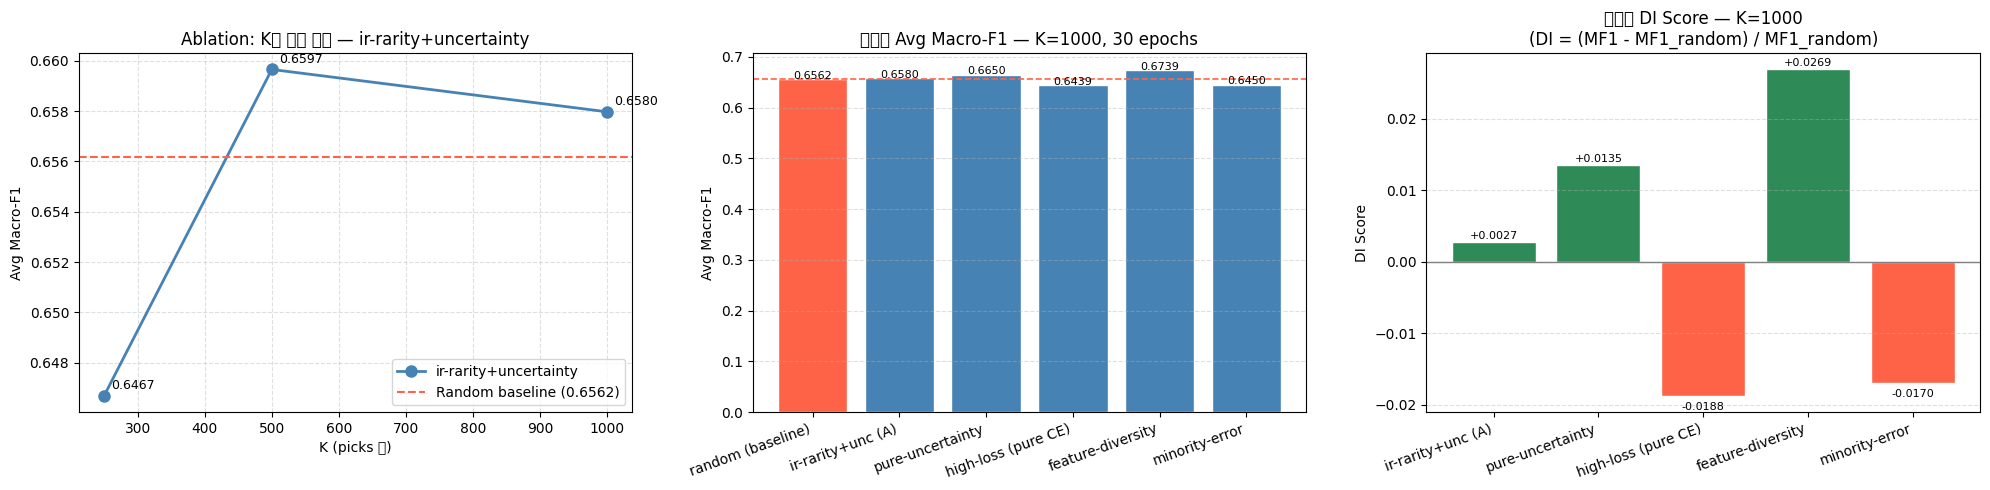

✓ level5_summary.png 저장


wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.


/usr/local/lib/python3.11/dist-packages/wandb/sdk/data_types/image.py:416: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing from font(s) DejaVu Sans.
  util.ensure_matplotlib_figure(data).savefig(buf, format=self.format)
/usr/local/lib/python3.11/dist-packages/wandb/sdk/data_types/image.py:416: UserWarning: Glyph 54620 (\N{HANGUL SYLLABLE HAN}) missing from font(s) DejaVu Sans.
  util.ensure_matplotlib_figure(data).savefig(buf, format=self.format)
/usr/local/lib/python3.11/dist-packages/wandb/sdk/data_types/image.py:416: UserWarning: Glyph 44228 (\N{HANGUL SYLLABLE GYE}) missing from font(s) DejaVu Sans.
  util.ensure_matplotlib_figure(data).savefig(buf, format=self.format)
/usr/local/lib/python3.11/dist-packages/wandb/sdk/data_types/image.py:416: UserWarning: Glyph 54952 (\N{HANGUL SYLLABLE HYO}) missing from font(s) DejaVu Sans.
  util.ensure_matplotlib_figure(data).savefig(buf, format=self.format)
/usr/local/lib/python3.11/dist-packages/wandb/sdk/data_types/image.py:416:

DI/feature-diversity,▁
DI/high-loss,▁
DI/ir-rarity+unc,▁
DI/minority-error,▁
DI/pure-uncertainty,▁
random_mf1,▁
strategy_mf1,▁
DI/feature-diversity,0.02692
DI/high-loss,-0.01877
DI/ir-rarity+unc,0.00272
DI/minority-error,-0.01699


In [17]:
# ── DI Score + Ablation curve + 전략 비교 통합 요약 ──────────────────────
import matplotlib.pyplot as plt

ablation_mf1[1000] = main_mf1

DI_A   = (main_mf1 - random_mf1) / random_mf1
DI_unc = (unc_mf1  - random_mf1) / random_mf1
DI_hl  = (hl_mf1   - random_mf1) / random_mf1
DI_div = (div_mf1  - random_mf1) / random_mf1
DI_me  = (me_mf1   - random_mf1) / random_mf1

strategy_results = {
    "random (baseline)":     (random_mf1, 0.0),
    "ir-rarity+unc (A)":     (main_mf1,   DI_A),
    "pure-uncertainty":      (unc_mf1,    DI_unc),
    "high-loss (pure CE)":   (hl_mf1,     DI_hl),
    "feature-diversity":     (div_mf1,    DI_div),
    "minority-error":        (me_mf1,     DI_me),
}

print("=" * 62)
print(f"  {'Strategy':<28}  {'MF1':>6}  {'DI':>8}")
print("-" * 62)
for name, (mf1, di) in strategy_results.items():
    print(f"  {name:<28}  {mf1:.4f}  {di:+.4f}")
print("=" * 62)

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20, 5))

# ── 좌: Ablation curve (Strategy A, K=250/500/1000 vs random) ─────────────
K_vals   = sorted(ablation_mf1.keys())
MF1_vals = [ablation_mf1[k] for k in K_vals]
ax1.plot(K_vals, MF1_vals, "o-", color="steelblue", lw=2, ms=8, label=STRATEGY_NAME_A)
ax1.axhline(random_mf1, color="tomato", ls="--",
            label=f"Random baseline ({random_mf1:.4f})")
for k, v in zip(K_vals, MF1_vals):
    ax1.annotate(f"{v:.4f}", (k, v), xytext=(5, 5),
                 textcoords="offset points", fontsize=9)
ax1.set_xlabel("K (picks 수)")
ax1.set_ylabel("Avg Macro-F1")
ax1.set_title(f"Ablation: K별 한계 효용 — {STRATEGY_NAME_A}")
ax1.legend(); ax1.grid(ls="--", alpha=0.4)

# ── 중: 전략별 Avg Macro-F1 비교 ──────────────────────────────────────────
names  = list(strategy_results.keys())
mf1s   = [v[0] for v in strategy_results.values()]
colors = ["tomato"] + ["steelblue"] * (len(names) - 1)
bars = ax2.bar(names, mf1s, color=colors, edgecolor="white")
ax2.axhline(random_mf1, color="tomato", ls="--", lw=1.2)
for bar, v in zip(bars, mf1s):
    ax2.text(bar.get_x() + bar.get_width() / 2, v + 0.001, f"{v:.4f}",
             ha="center", fontsize=8)
ax2.set_ylabel("Avg Macro-F1")
ax2.set_title("전략별 Avg Macro-F1 — K=1000, 30 epochs")
ax2.grid(axis="y", ls="--", alpha=0.4)
plt.setp(ax2.get_xticklabels(), rotation=20, ha="right")

# ── 우: 전략별 DI Score 비교 (random 제외) ────────────────────────────────
di_names  = [n for n in names if n != "random (baseline)"]
di_vals   = [strategy_results[n][1] for n in di_names]
di_colors = ["seagreen" if v >= 0 else "tomato" for v in di_vals]
bars3 = ax3.bar(di_names, di_vals, color=di_colors, edgecolor="white")
ax3.axhline(0, color="gray", lw=1.0, ls="-")
for bar, v in zip(bars3, di_vals):
    ypos = v + 0.0005 if v >= 0 else v - 0.002
    ax3.text(bar.get_x() + bar.get_width() / 2, ypos, f"{v:+.4f}",
             ha="center", fontsize=8)
ax3.set_ylabel("DI Score")
ax3.set_title("전략별 DI Score — K=1000\n(DI = (MF1 - MF1_random) / MF1_random)")
ax3.grid(axis="y", ls="--", alpha=0.4)
plt.setp(ax3.get_xticklabels(), rotation=20, ha="right")

fig.tight_layout()
plt.savefig("../level5_summary.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ level5_summary.png 저장")

lg_sum = WandbLogger(
    project=WANDB_PROJECT,
    run_name=f"level5-{STRATEGY_NAME_A}-summary",
    config={"strategy": STRATEGY_NAME_A},
    tags=WANDB_TAGS_A + ["summary"],
)
lg_sum.log({
    "random_mf1":          random_mf1,
    "strategy_mf1":        main_mf1,
    "DI/ir-rarity+unc":    DI_A,
    "DI/pure-uncertainty": DI_unc,
    "DI/high-loss":        DI_hl,
    "DI/feature-diversity":DI_div,
    "DI/minority-error":   DI_me,
})
lg_sum.log_table("ablation_curve",
                 ["K", "Avg-MF1"],
                 [[k, round(ablation_mf1[k], 4)] for k in K_vals])
lg_sum.log_table("strategy_comparison",
                 ["strategy", "avg_mf1", "DI_score"],
                 [[n, round(mf1, 4), round(di, 4)] for n, (mf1, di) in strategy_results.items()])
lg_sum.log_image("level5_summary", fig)
lg_sum.finish()


In [18]:
# ── 최고 전략 자동 선택 → level5_picks.json (Drive) + model2 ─────────────
DRIVE_PICKS = "/drive/MyDrive/aue8088-pa2/level5_picks.json"

strategy_registry = {
    "ir-rarity+unc":    (main_mf1,  score,               model_stratA),
    "pure-uncertainty": (unc_mf1,   score_unc,           model_unc),
    "high-loss":        (hl_mf1,    ce_loss_score,       model_hl),
    "feature-diversity":(div_mf1,   diversity_score,     model_div),
    "minority-error":   (me_mf1,    minority_error_score, model_me),
}

best_name = max(strategy_registry, key=lambda k: strategy_registry[k][0])
best_mf1, best_score_arr, model2 = strategy_registry[best_name]
best_di = (best_mf1 - random_mf1) / random_mf1
model2.eval()
print(f"✓ 최고 전략: {best_name}  MF1={best_mf1:.4f}  DI={best_di:+.4f} ({best_di*100:+.2f}%)")

torch.save({"state_dict": model2.state_dict()},
           f"{DRIVE_CKPT}/level5_final.pth")
print(f"✓ level5_final.pth → {DRIVE_CKPT}/level5_final.pth")

order_best = np.argsort(-best_score_arr)[:1000]
best_picks = []
for idx in order_best:
    s = set_b.samples[idx]
    best_picks.append({
        "image_id":  s.image_id,
        "weather":   int(s.weather),
        "scene":     int(s.scene),
        "timeofday": int(s.timeofday),
        "score":     float(best_score_arr[idx]),
    })

with open(DRIVE_PICKS, "w") as f:
    json.dump({
        "strategy":  best_name,
        "num_picks": len(best_picks),
        "avg_mf1":   float(best_mf1),
        "di_score":  float(best_di),
        "picks":     best_picks,
    }, f, indent=2, ensure_ascii=False)
print(f"✓ level5_picks.json → {DRIVE_PICKS}")


✓ 최고 전략: feature-diversity  MF1=0.6739  DI=+0.0269 (+2.69%)
✓ level5_final.pth → /drive/MyDrive/aue8088-pa2/checkpoints/level5_final.pth
✓ level5_picks.json → /drive/MyDrive/aue8088-pa2/level5_picks.json


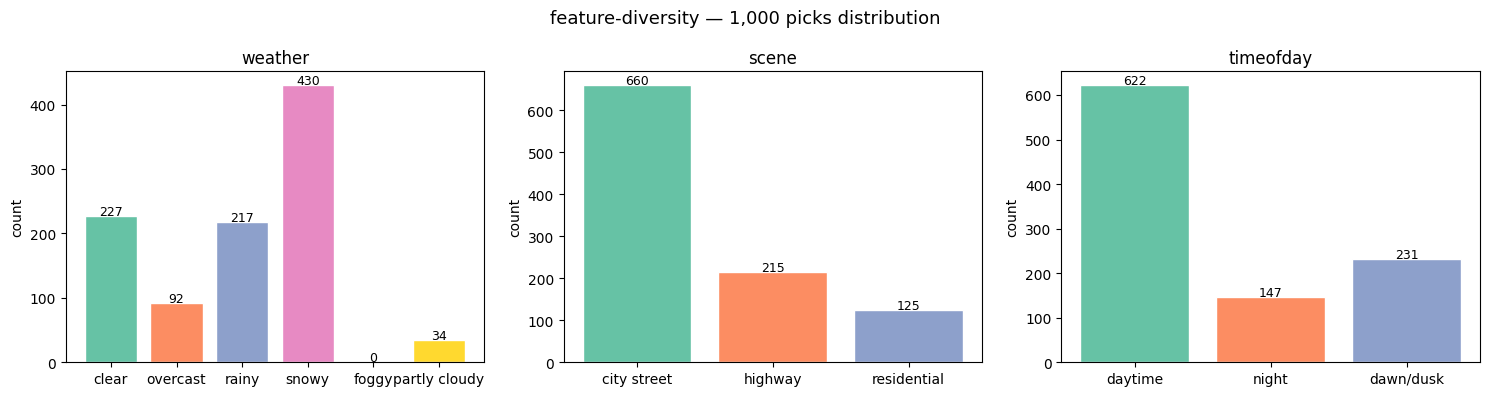

✓ level5_best_picks_bar.png 저장


In [19]:
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, a in zip(axes, ATTRIBUTES):
    cnt  = Counter(p[a] for p in best_picks)
    vals = [cnt.get(k, 0) for k in range(NUM_CLASSES[a])]
    bars = ax.bar(CLASS_NAMES[a], vals,
                  color=plt.cm.Set2.colors[:len(vals)], edgecolor="white")
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, v + 2, str(v),
                ha="center", fontsize=9)
    ax.set_title(a, fontsize=12)
    ax.set_ylabel("count")
fig.suptitle(f"{best_name} — 1,000 picks distribution", fontsize=13)
fig.tight_layout()
plt.savefig("../level5_best_picks_bar.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ level5_best_picks_bar.png 저장")


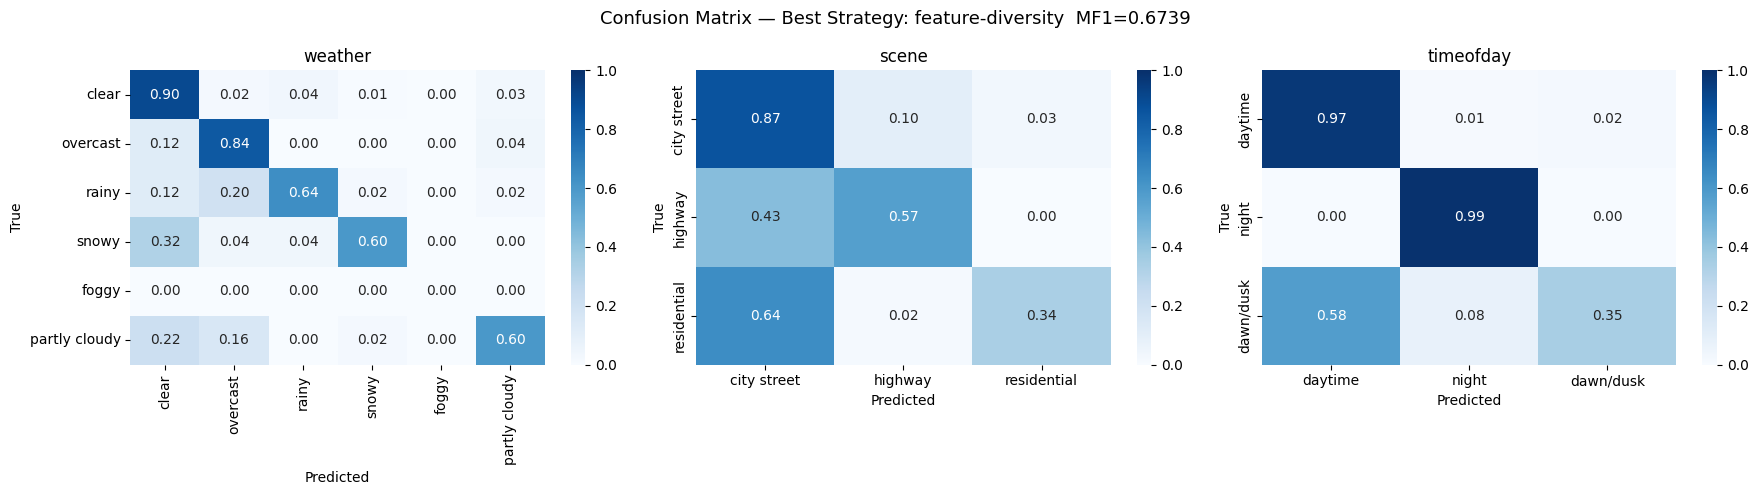

✓ level5_best_cm.png 저장


In [20]:
model2.eval()
_ds_val_cm = BDDAttrDataset("../data/set_a", "val", transform=eval_transform())
_ld_val_cm = DataLoader(_ds_val_cm, batch_size=64, shuffle=False, num_workers=2, pin_memory=True)
prd_cm, _, tgt_cm, _ = collect_predictions(model2, _ld_val_cm, device)
cms_best = confusion_matrices(prd_cm, tgt_cm)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, a in zip(axes, ATTRIBUTES):
    cm = cms_best[a].astype(float)
    cm_norm = cm / cm.sum(axis=1, keepdims=True).clip(min=1)
    sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Blues",
                xticklabels=CLASS_NAMES[a],
                yticklabels=CLASS_NAMES[a], ax=ax, vmin=0, vmax=1)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_title(a)
fig.suptitle(f"Confusion Matrix — Best Strategy: {best_name}  MF1={best_mf1:.4f}", fontsize=13)
fig.tight_layout()
plt.savefig("../level5_best_cm.png", dpi=150, bbox_inches="tight")
plt.show()
print("✓ level5_best_cm.png 저장")


## Curation Report — 필수

Final PPT 에 다음을 포함하세요.
- **선별 알고리즘** (의사코드 또는 1페이지 다이어그램).
- 본인 picks 1,000장의 **분포** — (예측된) weather × scene × timeofday — 를 heatmap 또는 stacked bar 로 시각화.
- **Random-1000 baseline** 결과와 본인의 **DI score** 비교.
- **Ablation**: 250 / 500 / 1000 장을 골랐을 때의 변화 — 추가 데이터의 한계 효용이 보이는지 확인.

여러 전략을 시험했다면 wandb 의 같은 프로젝트에 `STRATEGY_NAME` 만 바꿔서 별도 Run 으로 누적하세요. 학습 곡선·분포·DI score 비교가 한 페이지에 모입니다.